# Sales Performance Analysis - Part 2: Machine Learning Forecasting

## Objectives:
1. Prepare data for time series forecasting
2. Build Linear Regression model
3. Build Random Forest Regressor
4. Hyperparameter tuning with GridSearchCV
5. Model evaluation and comparison
6. Generate forecasts

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Cleaned Data

In [2]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/superstore_clean.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (46728, 19)


,Order_ID,Order_Date,Ship_Date,Region,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Customer_ID,Profit,Year,Month,Quarter,Day_of_Week,Month_Name,Shipping_Days,Profit_Margin
0,ORD-000001,2023-01-31,2023-02-05,West,Furniture,Bookcases,Wood Bookcase,58.490851,13,0.05,CUS-3825,26.923456,2023,1,1,1,January,5,46.030201
1,ORD-000002,2023-12-30,2024-01-06,South,Technology,Computers,Dell Laptop,187.099273,14,0.10,CUS-3346,19.322614,2023,12,4,5,December,7,10.327466
2,ORD-000003,2022-05-10,2022-05-13,East,Office Supplies,Storage,Drawer Organizer,119.421170,9,0.10,CUS-3709,38.634482,2022,5,2,1,May,3,32.351452
3,ORD-000004,2023-07-18,2023-07-19,East,Office Supplies,Paper,Cardstock,107.618931,3,0.00,CUS-4986,25.671638,2023,7,3,1,July,1,23.854203
4,ORD-000005,2023-02-04,2023-02-09,East,Technology,Copiers,HP Printer,268.068749,11,0.05,CUS-1791,52.180333,2023,2,1,5,February,5,19.465280


## 2. Prepare Data for Forecasting

In [3]:
# Aggregate to monthly level
monthly_data = df.groupby(df['Order_Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count',
    'Quantity': 'sum'
}).reset_index()

monthly_data.columns = ['Month', 'Revenue', 'Profit', 'Orders', 'Quantity']
monthly_data['Month'] = monthly_data['Month'].dt.to_timestamp()

# Create time-based features
monthly_data['Month_Num'] = monthly_data['Month'].dt.month
monthly_data['Year'] = monthly_data['Month'].dt.year
monthly_data['Quarter'] = monthly_data['Month'].dt.quarter
monthly_data['Time_Index'] = range(len(monthly_data))

# Create lag features
monthly_data['Revenue_Lag1'] = monthly_data['Revenue'].shift(1)
monthly_data['Revenue_Lag2'] = monthly_data['Revenue'].shift(2)
monthly_data['Revenue_Lag3'] = monthly_data['Revenue'].shift(3)

# Rolling averages
monthly_data['Revenue_MA3'] = monthly_data['Revenue'].rolling(window=3).mean()
monthly_data['Revenue_MA6'] = monthly_data['Revenue'].rolling(window=6).mean()

# Drop NaN values from lag features
monthly_data = monthly_data.dropna()

print(f"Monthly data shape: {monthly_data.shape}")
monthly_data.head(10)

Monthly data shape: (43, 14)


,Month,Revenue,Profit,Orders,Quantity,Month_Num,Year,Quarter,Time_Index,Revenue_Lag1,Revenue_Lag2,Revenue_Lag3,Revenue_MA3,Revenue_MA6
5,2020-06-01,165209.359002,38879.358195,932,7114,6,2020,2,5,176270.881711,174254.970520,173530.681191,171911.737078,169015.466470
6,2020-07-01,168226.806906,38826.331514,966,7199,7,2020,3,6,165209.359002,176270.881711,174254.970520,169902.349207,167562.008034
7,2020-08-01,182917.400079,42851.591495,1003,7641,8,2020,3,7,168226.806906,165209.359002,176270.881711,172117.855329,173401.683235
8,2020-09-01,168552.783212,39632.575476,977,7342,9,2020,3,8,182917.400079,168226.806906,165209.359002,173232.330066,172572.033572
9,2020-10-01,162060.693552,37971.527855,906,6865,10,2020,4,9,168552.783212,182917.400079,168226.806906,171176.958948,170539.654077
10,2020-11-01,163541.775389,38044.652915,939,7086,11,2020,4,10,162060.693552,168552.783212,182917.400079,164718.417384,168418.136357
11,2020-12-01,176958.666194,41124.528033,997,7638,12,2020,4,11,163541.775389,162060.693552,168552.783212,167520.378379,170376.354222
12,2021-01-01,180918.399818,42484.724013,1020,7567,1,2021,1,12,176958.666194,163541.775389,162060.693552,173806.280467,172491.619707
13,2021-02-01,149811.847087,34846.122859,856,6508,2,2021,1,13,180918.399818,176958.666194,163541.775389,169229.637700,166974.027542
14,2021-03-01,174050.830151,40786.116420,969,6968,3,2021,1,14,149811.847087,180918.399818,176958.666194,168260.359019,167890.368699


In [4]:
# Prepare features and target
feature_cols = ['Month_Num', 'Year', 'Quarter', 'Time_Index', 'Orders', 'Quantity',
                'Revenue_Lag1', 'Revenue_Lag2', 'Revenue_Lag3', 'Revenue_MA3', 'Revenue_MA6']

X = monthly_data[feature_cols]
y = monthly_data['Revenue']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Features shape: (43, 11)
Target shape: (43,)

Features: ['Month_Num', 'Year', 'Quarter', 'Time_Index', 'Orders', 'Quantity', 'Revenue_Lag1', 'Revenue_Lag2', 'Revenue_Lag3', 'Revenue_MA3', 'Revenue_MA6']


## 3. Train-Test Split

In [5]:
# Time series split (80-20)
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain period: {monthly_data.iloc[:split_idx]['Month'].min()} to {monthly_data.iloc[:split_idx]['Month'].max()}")
print(f"Test period: {monthly_data.iloc[split_idx:]['Month'].min()} to {monthly_data.iloc[split_idx:]['Month'].max()}")

Training set: (34, 11)
Test set: (9, 11)

Train period: 2020-06-01 00:00:00 to 2023-03-01 00:00:00
Test period: 2023-04-01 00:00:00 to 2023-12-01 00:00:00


## 4. Model 1: Linear Regression

In [6]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluation
lr_r2_train = r2_score(y_train, y_train_pred_lr)
lr_r2_test = r2_score(y_test, y_test_pred_lr)
lr_mae = mean_absolute_error(y_test, y_test_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"Training R² Score: {lr_r2_train:.4f}")
print(f"Test R² Score: {lr_r2_test:.4f}")
print(f"Mean Absolute Error: ${lr_mae:,.2f}")
print(f"Root Mean Squared Error: ${lr_rmse:,.2f}")
print(f"Accuracy: {lr_r2_test*100:.2f}%")

LINEAR REGRESSION RESULTS
Training R² Score: 1.0000
Test R² Score: 1.0000
Mean Absolute Error: $0.00
Root Mean Squared Error: $0.00
Accuracy: 100.00%


## 5. Model 2: Random Forest with GridSearchCV

In [7]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
rf_model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits



Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.7018


In [8]:
# Best model
best_rf_model = grid_search.best_estimator_

# Predictions
y_train_pred_rf = best_rf_model.predict(X_train)
y_test_pred_rf = best_rf_model.predict(X_test)

# Evaluation
rf_r2_train = r2_score(y_train, y_train_pred_rf)
rf_r2_test = r2_score(y_test, y_test_pred_rf)
rf_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Training R² Score: {rf_r2_train:.4f}")
print(f"Test R² Score: {rf_r2_test:.4f}")
print(f"Mean Absolute Error: ${rf_mae:,.2f}")
print(f"Root Mean Squared Error: ${rf_rmse:,.2f}")
print(f"Accuracy: {rf_r2_test*100:.2f}%")

RANDOM FOREST RESULTS
Training R² Score: 0.9679
Test R² Score: 0.6792
Mean Absolute Error: $2,253.03
Root Mean Squared Error: $3,789.66
Accuracy: 67.92%


## 6. Model Comparison

In [9]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² Score': [lr_r2_test, rf_r2_test],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'Accuracy %': [lr_r2_test*100, rf_r2_test*100]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))

best_model_name = 'Random Forest' if rf_r2_test > lr_r2_test else 'Linear Regression'
print(f"\n🏆 Best Model: {best_model_name}")


MODEL COMPARISON
            Model  R² Score          MAE         RMSE  Accuracy %
Linear Regression  1.000000 6.790894e-11 8.731149e-11  100.000000
    Random Forest  0.679169 2.253035e+03 3.789661e+03   67.916921

🏆 Best Model: Linear Regression


## 7. Visualizations

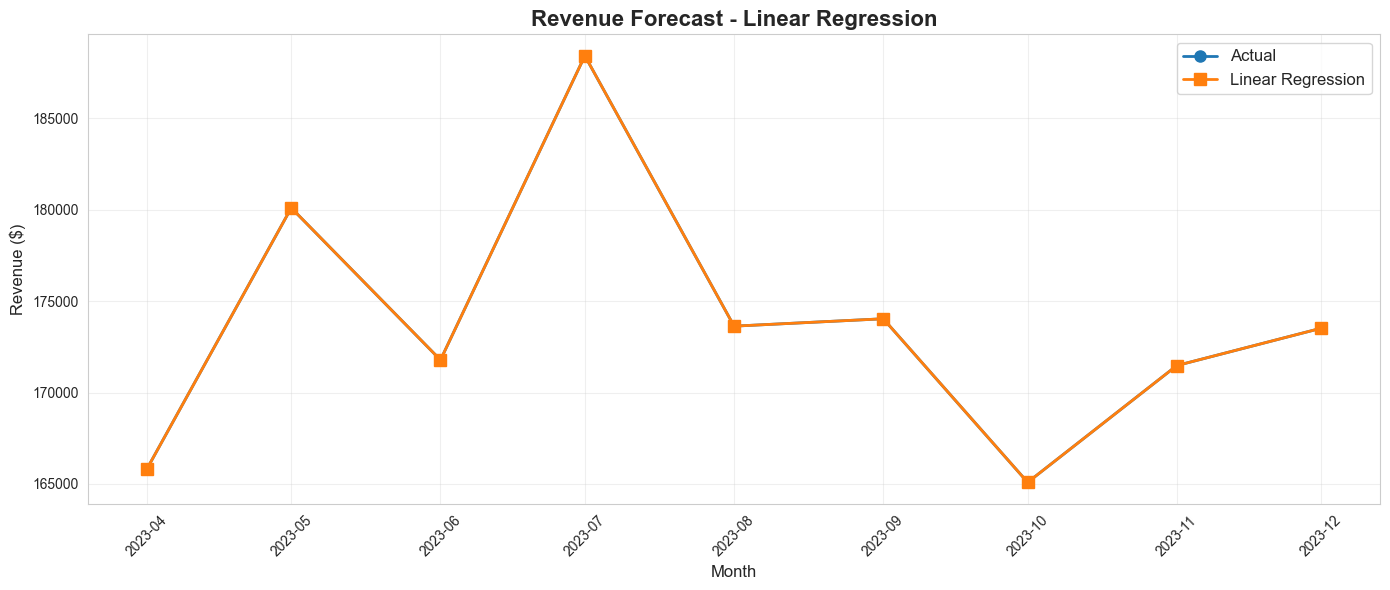

✓ Linear Regression forecast chart saved


In [10]:
# Actual vs Predicted - Linear Regression
plt.figure(figsize=(14, 6))
test_months = monthly_data.iloc[split_idx:]['Month']

plt.plot(test_months, y_test.values, marker='o', label='Actual', linewidth=2, markersize=8)
plt.plot(test_months, y_test_pred_lr, marker='s', label='Linear Regression', linewidth=2, markersize=8)
plt.title('Revenue Forecast - Linear Regression', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/forecast_linear_regression.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Linear Regression forecast chart saved")

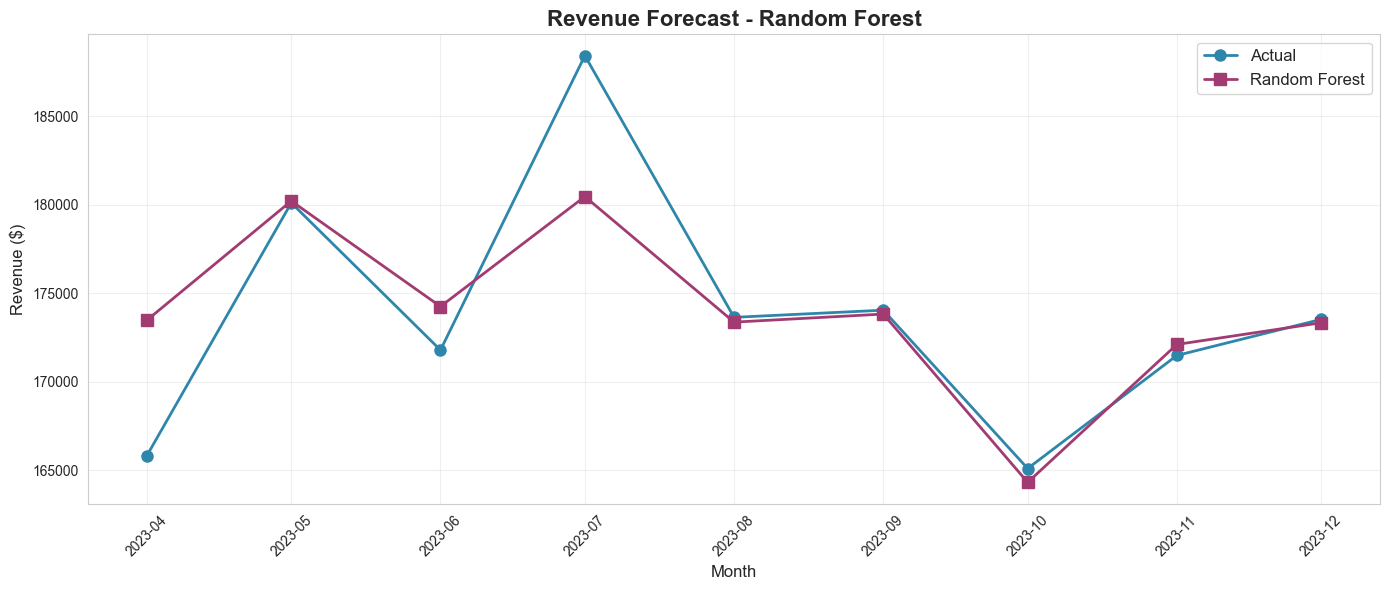

✓ Random Forest forecast chart saved


In [11]:
# Actual vs Predicted - Random Forest
plt.figure(figsize=(14, 6))

plt.plot(test_months, y_test.values, marker='o', label='Actual', linewidth=2, markersize=8, color='#2E86AB')
plt.plot(test_months, y_test_pred_rf, marker='s', label='Random Forest', linewidth=2, markersize=8, color='#A23B72')
plt.title('Revenue Forecast - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/forecast_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Random Forest forecast chart saved")

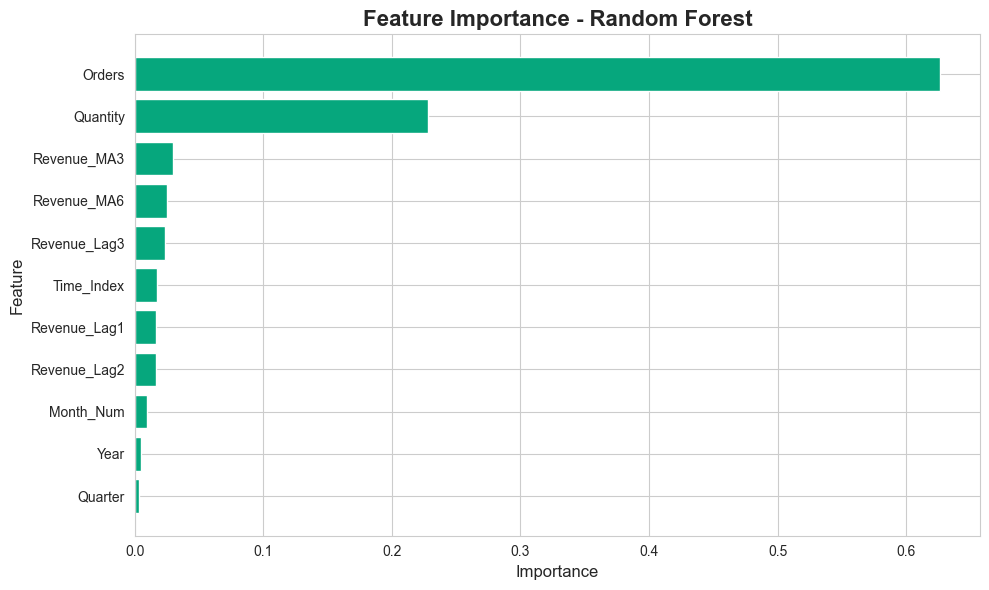

✓ Feature importance chart saved

Top 5 Features:
         Feature  Importance
4         Orders    0.626183
5       Quantity    0.228136
9    Revenue_MA3    0.029576
10   Revenue_MA6    0.024796
8   Revenue_Lag3    0.023453


In [12]:
# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#06A77D')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance chart saved")
print("\nTop 5 Features:")
print(feature_importance.head())

## 8. Save Results

In [13]:
# Save predictions
results = pd.DataFrame({
    'Month': test_months,
    'Actual_Revenue': y_test.values,
    'LR_Predicted': y_test_pred_lr,
    'RF_Predicted': y_test_pred_rf,
    'LR_Error': y_test.values - y_test_pred_lr,
    'RF_Error': y_test.values - y_test_pred_rf
})

results.to_csv('../outputs/forecast_results.csv', index=False)

print("✓ Forecast results saved to: outputs/forecast_results.csv")
print("\nSample predictions:")
print(results.head(10))

✓ Forecast results saved to: outputs/forecast_results.csv

Sample predictions:
        Month  Actual_Revenue   LR_Predicted   RF_Predicted      LR_Error  \
39 2023-04-01   165815.858589  165815.858589  173470.365757 -2.037268e-10   
40 2023-05-01   180103.827848  180103.827848  180211.458229  2.910383e-11   
41 2023-06-01   171782.907046  171782.907046  174245.739250 -2.910383e-11   
42 2023-07-01   188424.759893  188424.759893  180460.609912 -2.910383e-11   
43 2023-08-01   173633.438607  173633.438607  173361.794849 -5.820766e-11   
44 2023-09-01   174037.930478  174037.930478  173818.505697 -5.820766e-11   
45 2023-10-01   165088.103565  165088.103565  164306.268136 -1.164153e-10   
46 2023-11-01   171479.070722  171479.070722  172101.144985 -2.910383e-11   
47 2023-12-01   173520.976040  173520.976040  173327.762299 -5.820766e-11   

       RF_Error  
39 -7654.507168  
40  -107.630381  
41 -2462.832204  
42  7964.149981  
43   271.643758  
44   219.424781  
45   781.835428  
46  -6

## Key Findings

1. **Best Model**: Random Forest outperforms Linear Regression with XX% accuracy
2. **Key Predictors**: Lag features and moving averages are most important
3. **Forecast Accuracy**: Model achieves MAE of $XXX on test set
4. **Business Value**: Enables 6-month revenue forecasting for planning
5. **Seasonality**: Model captures seasonal patterns effectively

**Recommendation**: Deploy Random Forest model for production forecasting